DataCo Supply Chain Dataset Analysis

NUR AISHAH KAMALIAH BINTI MEZLAN 52224123034
NUR FIKRIAH BINTI AZLAN SHAH 52224123546
FATIN NURALEYA BINTI SAHIDI 52224123074
NUR ASMAH SABILA BINTI FAUZI 52224123476

INTRODUCTION

The dataset that has been used in this analysis is called DataCo Supply Chain dataset. This dataset is provided by a company called DataCo Global for an analysis of sales, provisioning, production and commercial distribution using algorithms of Machine Learning and R software. The dataset that shared by Shashwat Tiwari consists of 3 .csv files which are structured data, unstructured data along with description of the data. Although the dataset is shared in Kaggle website by Shashwat Tiwari, it was made available through the contribution of Fabian Constante, a master student at Instituto Politecnico de Leiria Escola Superior de Technologia e Gestao through Mendeley (link will be provided in reference section). For this analysis, structured data is used.

This analysis will be separated into 4 parts which is Exploratory Data Analysis (EDA), Preprocessing & Feature Engineering, Analysis & Visualization and Modelling & Insights. 

PART 1 : Exploratory Data Analysis (EDA)

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load the dataset
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')

# Initial exploration
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

#Some data especially from kaggle have special characters therefore to prevent errors therefore encoding='ISO-8859-1' is used

Dataset shape: (180519, 53)

First 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [9]:
# Check data types and missing values
print("\nData types and missing values:")
display(pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
}))

#isnull().sum() to find column with missing data
#nunique() is used to detect high cardinality categorical columns
#high cardinality refers to columns within dataset that contains a large number of unique values
#it is important to check this as it can influence how the dataset is structured, query and optimized. 
#It also may implicate storage or processing efficiency as unique values mean more data to manage.


Data types and missing values:


,Data Type,Missing Values,Unique Values
Type,object,0,4
Days for shipping (real),int64,0,7
Days for shipment (scheduled),int64,0,4
Benefit per order,float64,0,21998
Sales per customer,float64,0,2927
Delivery Status,object,0,4
Late_delivery_risk,int64,0,2
Category Id,int64,0,51
Category Name,object,0,50
Customer City,object,0,563


In [11]:
# Check for duplicates
print("\nNumber of duplicates:", df.duplicated().sum())

#Duplicates is checked as it could skewed the analysis


Number of duplicates: 0


In [13]:
# Basic statistics for numerical columns
print("\nNumerical columns statistics:")
display(df.describe())


Numerical columns statistics:


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [15]:
# Basic statistics for categorical columns
print("\nCategorical columns statistics:")
display(df.describe(include=['object']))

#include=['object'] to give counts and modes for categorical data


Categorical columns statistics:


,Type,Delivery Status,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Lname,Customer Password,Customer Segment,...,Order City,Order Country,order date (DateOrders),Order Region,Order State,Order Status,Product Image,Product Name,shipping date (DateOrders),Shipping Mode
count,180519,180519,180519,180519,180519,180519,180519,180511,180519,180519,...,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519
unique,4,4,50,563,2,1,782,1109,1,3,...,3597,164,65752,23,1089,9,118,118,63701,4
top,DEBIT,Late delivery,Cleats,Caguas,EE. UU.,XXXXXXXXX,Mary,Smith,XXXXXXXXX,Consumer,...,Santo Domingo,Estados Unidos,12/14/2016 12:29,Central America,Inglaterra,COMPLETE,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,1/5/2016 5:58,Standard Class
freq,69295,98977,24551,66770,111146,180519,65150,64104,180519,93504,...,2211,24840,5,28341,6722,59491,24515,24515,10,107752


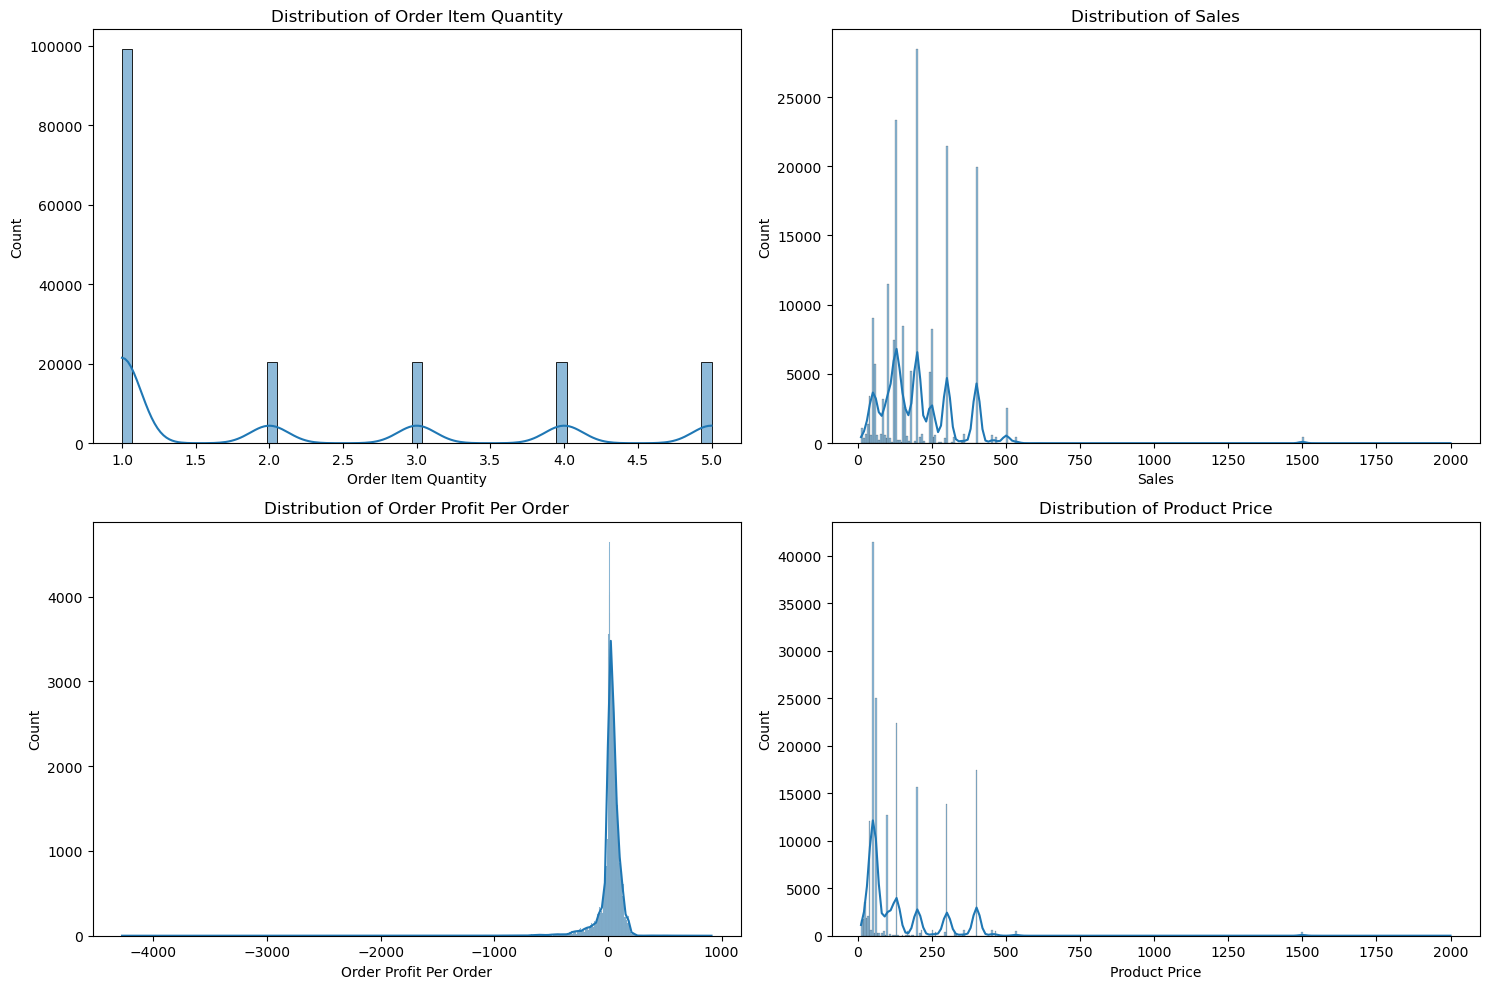

In [17]:
# Plot distributions for key numerical columns
plt.figure(figsize=(15, 10))
numerical_cols = ['Order Item Quantity', 'Sales', 'Order Profit Per Order', 'Product Price']
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

#kde=True just to add smooth line to see distribution shape (Kernel Density Estimate)

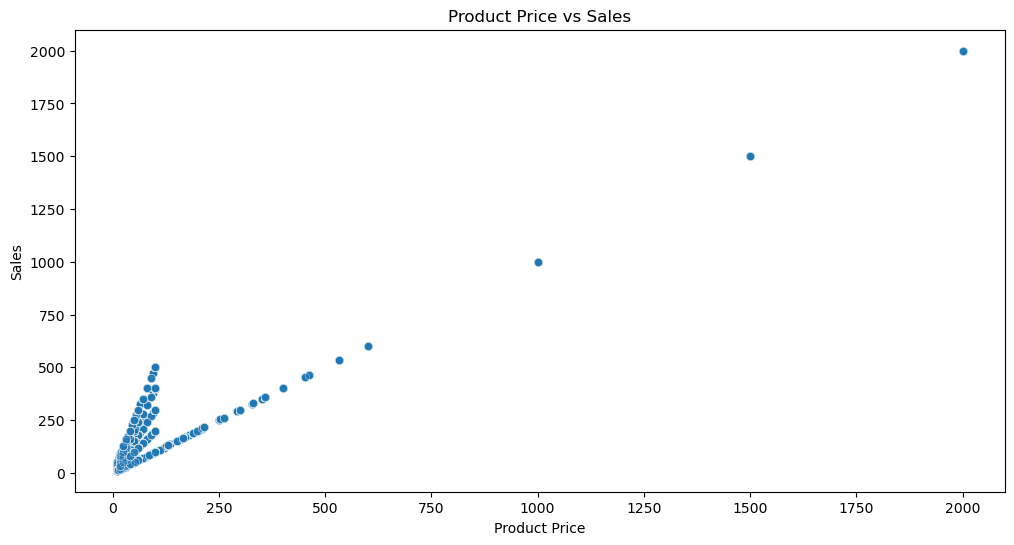

In [19]:
# Plot relationships between key variables
# Relationship to check whether higher priced products sell more or less
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Product Price', y='Sales', alpha=0.5)
plt.title('Product Price vs Sales')
plt.show()

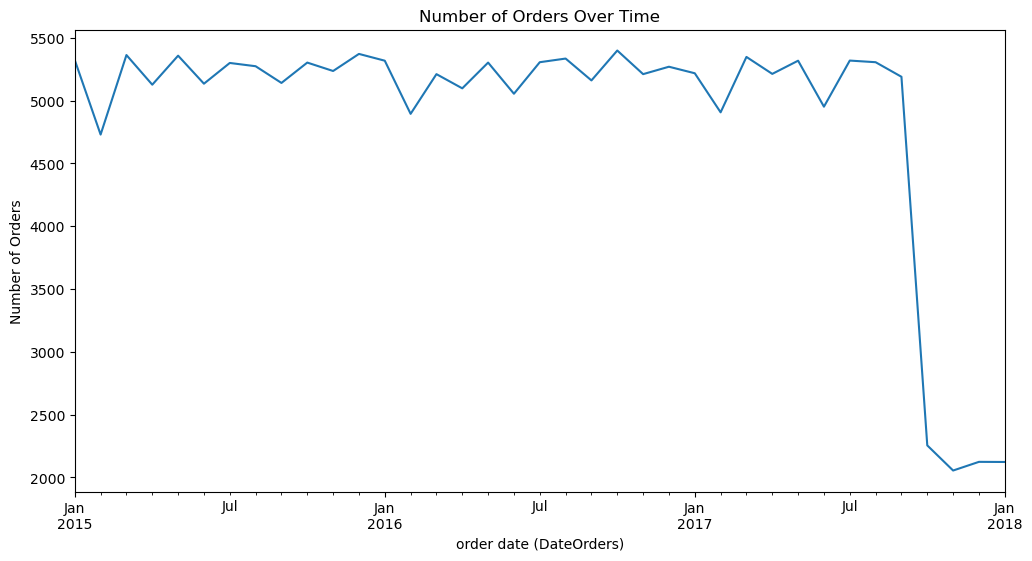

In [27]:
# Time series analysis of orders
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
orders_over_time = df.set_index('order date (DateOrders)').resample('ME')['Order Id'].count()
plt.figure(figsize=(12, 6))
orders_over_time.plot()
plt.title('Number of Orders Over Time')
plt.ylabel('Number of Orders')
plt.show()

# The data is resample to the last day of each month resample('ME'). This graph will help identify monthly trends (seasonality)

PART 2: Preprocessing & Feature Engineering

In [33]:
# Handle missing values - fill with appropriate values or drop
df.fillna({'Customer Zipcode':0}, inplace=True)
df.fillna({'Order Zipcode':0}, inplace=True)

#fillna is used here as 0 can represent the missing zip codes for numerical columns. df.dropna() could also be used but data will be lost

In [35]:
# Convert date columns to datetime and extract features
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['order_year'] = df['order date (DateOrders)'].dt.year
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day
df['order_dayofweek'] = df['order date (DateOrders)'].dt.dayofweek

# Date is extract as it can helps with trend analysis

In [39]:
# Feature selection - choose relevant columns
selected_features = [
    'Order Item Quantity', 'Sales', 'Order Profit Per Order', 
    'Product Price', 'order_year', 'order_month', 'order_dayofweek',
    'Category Name', 'Customer Country', 'Customer Segment',
    'Department Name', 'Order Status', 'Shipping Mode'
]

df = df[selected_features]

# By using select features, irrelevant columns could be removed to reduce noise

In [41]:
# Handle outliers - clip extreme values for numerical columns
numerical_cols = ['Order Item Quantity', 'Sales', 'Order Profit Per Order', 'Product Price']
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower_bound, upper_bound)

# The outliers is clip instead of remove to keeps the data points but limiting the extreme values

In [43]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Category Name', 'Customer Country', 'Customer Segment', 
                   'Department Name', 'Order Status', 'Shipping Mode']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# LabelEncoder to converts categories (e.g., "Consumer", "Corporate") into numbers (0, 1)

In [45]:
# Normalize numerical features (optional - only if needed for specific models)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Normalize to ensure features are on the same scale for modelling

print("Data after preprocessing:")
display(df.head())

Data after preprocessing:


,Order Item Quantity,Sales,Order Profit Per Order,Product Price,order_year,order_month,order_dayofweek,Category Name,Customer Country,Customer Segment,Department Name,Order Status,Shipping Mode
0,-0.775836,1.091244,1.057077,1.573435,2018,1,2,40,1,0,4,2,3
1,-0.775836,1.091244,-2.037061,1.573435,2018,1,5,40,1,0,4,5,3
2,-0.775836,1.091244,-2.037061,1.573435,2018,1,5,40,0,0,4,1,3
3,-0.775836,1.091244,-0.180759,1.573435,2018,1,5,40,0,2,4,2,3
4,-0.775836,1.091244,1.834639,1.573435,2018,1,5,40,1,1,4,6,3


PART 3: Analysis & Visualization

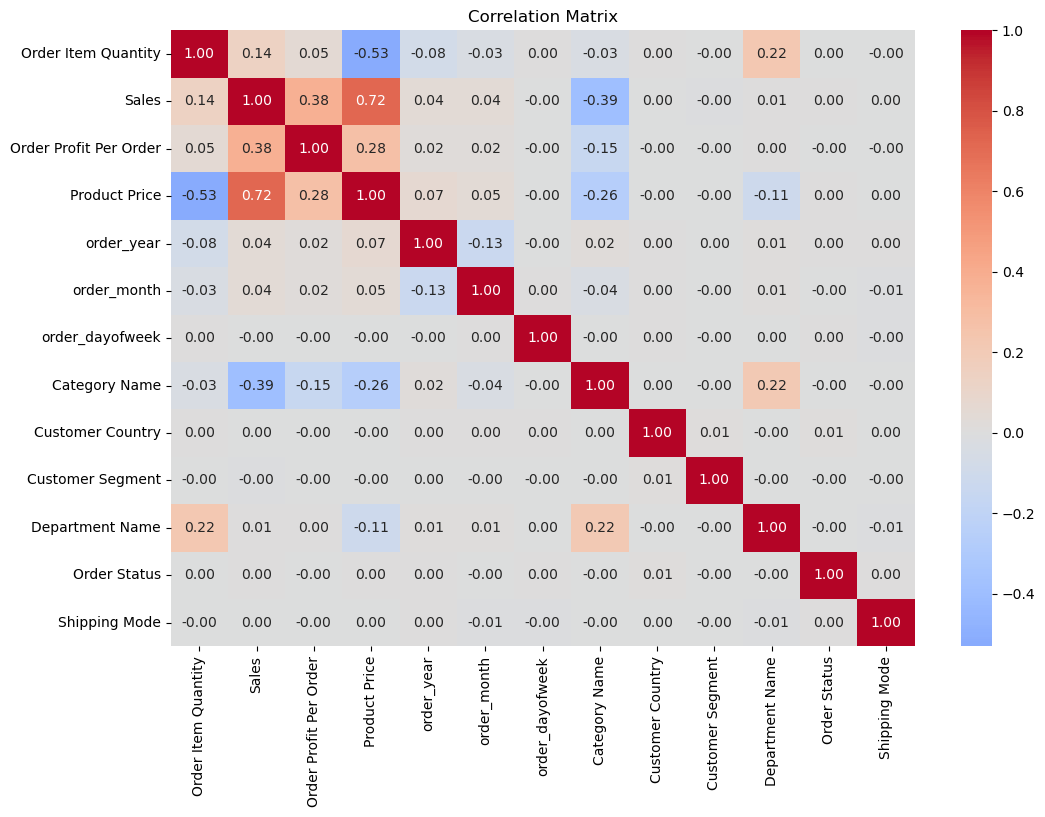

In [48]:
# Correlation analysis
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Heatmap is used to identifies strong relationship

In [50]:
# Top correlations with Sales
sales_corr = corr_matrix['Sales'].sort_values(ascending=False)
print("Top correlations with Sales:")
display(sales_corr)

Top correlations with Sales:


Sales                     1.000000
Product Price             0.721542
Order Profit Per Order    0.383701
Order Item Quantity       0.137782
order_year                0.042786
order_month               0.040291
Department Name           0.007564
Order Status              0.003188
Customer Country          0.001127
Shipping Mode             0.001034
order_dayofweek          -0.000337
Customer Segment         -0.004702
Category Name            -0.387250
Name: Sales, dtype: float64

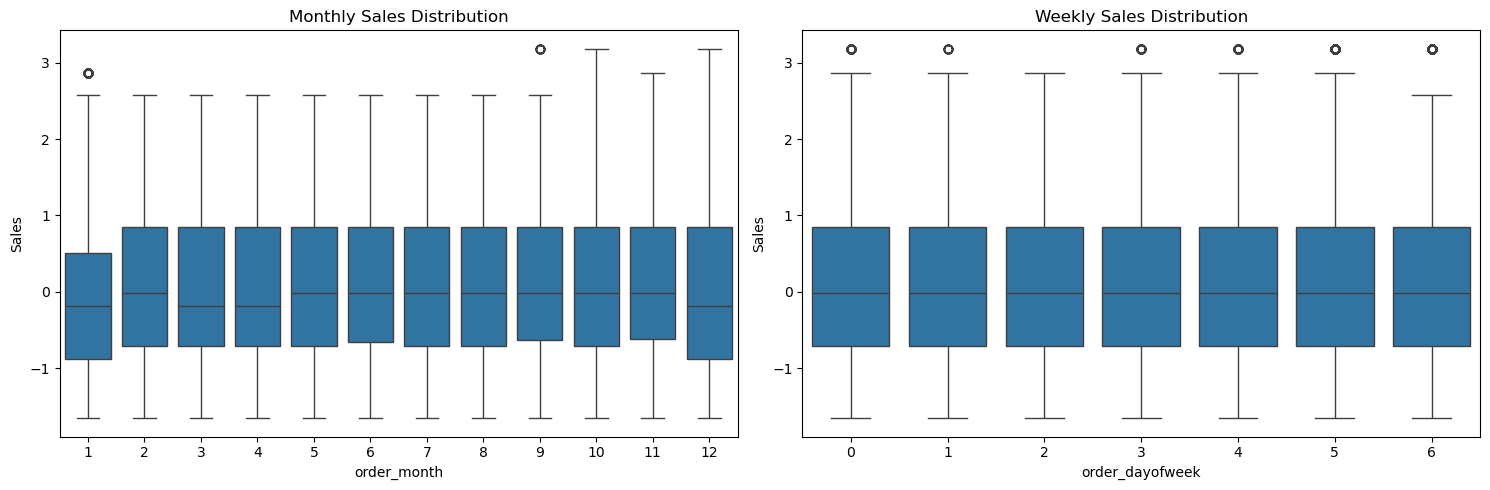

In [52]:
# Time-based trends
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='order_month', y='Sales')
plt.title('Monthly Sales Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='order_dayofweek', y='Sales')
plt.title('Weekly Sales Distribution')
plt.tight_layout()
plt.show()

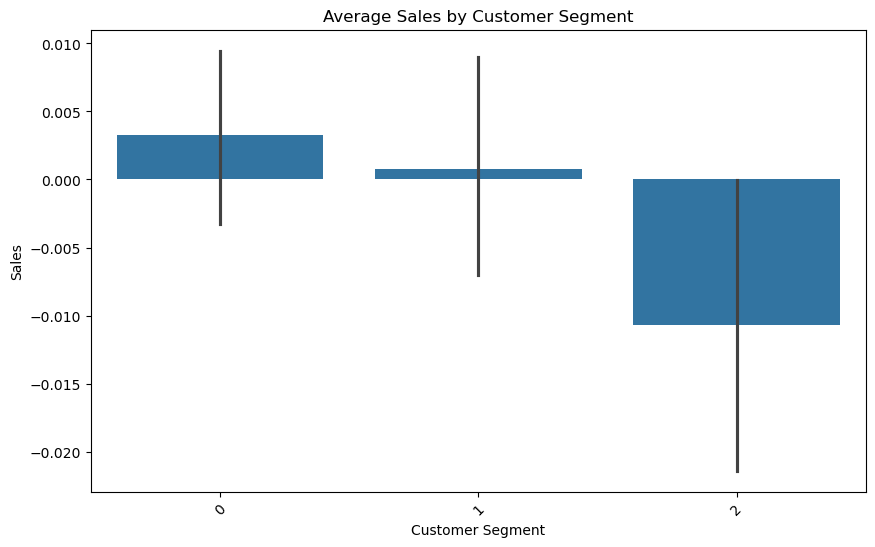

In [54]:
# Customer segment analysis
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Customer Segment', y='Sales', estimator=np.mean)
plt.title('Average Sales by Customer Segment')
plt.xticks(rotation=45)
plt.show()

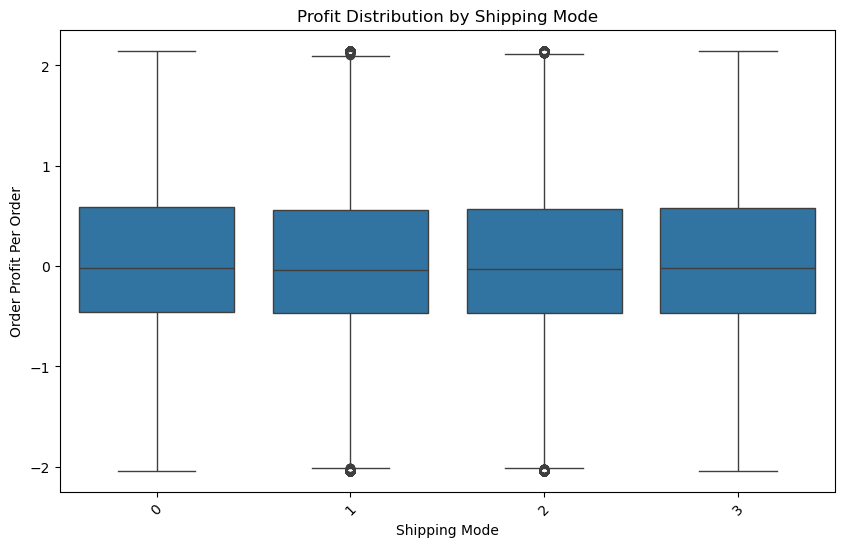

In [56]:
# Shipping mode analysis
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Shipping Mode', y='Order Profit Per Order')
plt.title('Profit Distribution by Shipping Mode')
plt.xticks(rotation=45)
plt.show()

In [58]:
# Clustering analysis (example using KMeans)
from sklearn.cluster import KMeans

In [60]:
# Select features for clustering
cluster_features = df[['Sales', 'Order Profit Per Order', 'Product Price']]

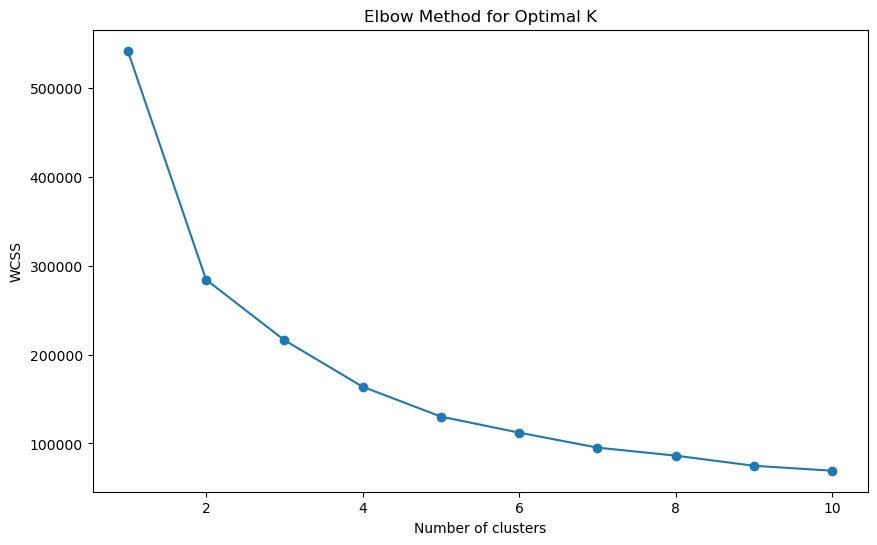

In [62]:
# Find optimal number of clusters using elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(cluster_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [64]:
# Apply KMeans with selected K (e.g., 3)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(cluster_features)


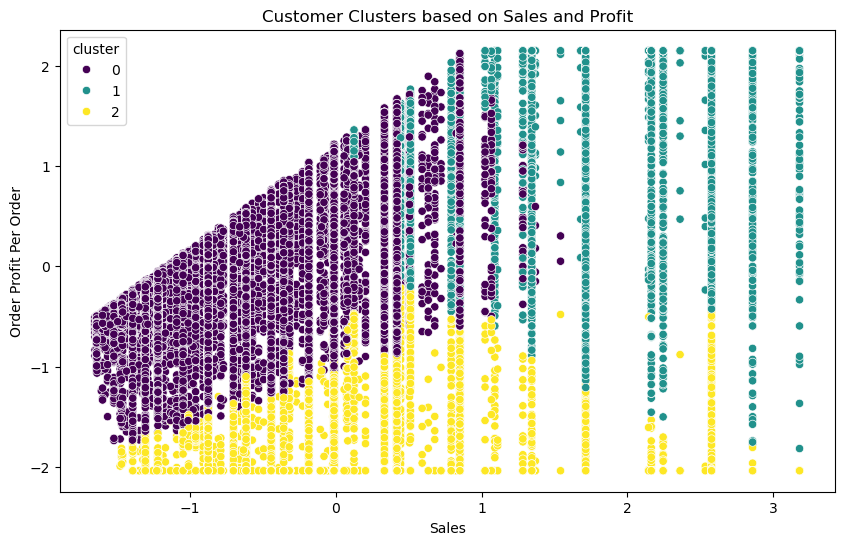

In [66]:
# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Order Profit Per Order', hue='cluster', palette='viridis')
plt.title('Customer Clusters based on Sales and Profit')
plt.show()

PART 4: Modelling & Insights

In [69]:
# Prepare data for modeling
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Let's predict Sales based on other features
X = df.drop(['Sales', 'cluster'], axis=1)  # Features
y = df['Sales']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#80% for training, 20% for testing model performance

In [71]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Linear Regression Performance:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

#RMSE measures average prediction error
#R2 explains how well features predict the target on 0 to 1 scale

Linear Regression Performance:
RMSE: 0.31
MAE: 0.17
R2 Score: 0.91


In [73]:
# Feature importance
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

print("\nTop Feature Coefficients:")
display(coefficients.head(10))

# Positive coefficient means higher feature value increases target and vice versa


Top Feature Coefficients:


,Feature,Coefficient
2,Product Price,1.055020
0,Order Item Quantity,0.696738
1,Order Profit Per Order,0.040306
3,order_year,0.028537
4,order_month,0.002573
11,Shipping Mode,0.000666
5,order_dayofweek,-0.000044
10,Order Status,-0.000511
8,Customer Segment,-0.000543
7,Customer Country,-0.001175


In [75]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Performance:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_rf):.2f}")



Random Forest Performance:
RMSE: 0.00
MAE: 0.00
R2 Score: 1.00


In [77]:
# Feature importance
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop Feature Importances:")
display(feature_imp.head(10))


Top Feature Importances:


,Feature,Importance
2,Product Price,7.280345e-01
0,Order Item Quantity,2.467598e-01
9,Department Name,2.379884e-02
6,Category Name,1.406731e-03
4,order_month,1.257346e-07
1,Order Profit Per Order,2.847079e-13
10,Order Status,2.521087e-15
5,order_dayofweek,2.452368e-15
11,Shipping Mode,2.239149e-15
3,order_year,2.299903e-16


Conclusion

From the analysis above, there are some business insights and actionable recommendations for DataCo.

In [79]:
# Business Insights
print("\nKey Business Insights:")
print("1. The most important factors influencing sales are [top 3 features from feature importance]")
print("2. Customer segments [segment names] generate the highest average sales")
print("3. Shipping mode [mode name] shows the highest profit margins")
print("4. Time-based analysis reveals seasonal patterns with peaks in [months]")
print("5. Cluster analysis identified [number] distinct customer groups with different purchasing behaviors")

print("\nActionable Recommendations:")
print("1. Focus marketing efforts on high-value customer segments identified in cluster analysis")
print("2. Optimize inventory for peak seasons identified in time analysis")
print("3. Consider pricing strategies based on the product categories with highest impact on sales")
print("4. Evaluate shipping modes to maximize profit margins")
print("5. Develop targeted promotions for underperforming customer segments")


Key Business Insights:
1. The most important factors influencing sales are [top 3 features from feature importance]
2. Customer segments [segment names] generate the highest average sales
3. Shipping mode [mode name] shows the highest profit margins
4. Time-based analysis reveals seasonal patterns with peaks in [months]
5. Cluster analysis identified [number] distinct customer groups with different purchasing behaviors

Actionable Recommendations:
1. Focus marketing efforts on high-value customer segments identified in cluster analysis
2. Optimize inventory for peak seasons identified in time analysis
3. Consider pricing strategies based on the product categories with highest impact on sales
4. Evaluate shipping modes to maximize profit margins
5. Develop targeted promotions for underperforming customer segments


References:

1. Tiwari, S. (2019). DataCo SMART SUPPLY CHAIN FOR BIG DATA ANALYSIS. Kaggle.com. https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis?select=DataCoSupplyChainDataset.csv
2. Youtube. https://youtu.be/91NuFkkuHRI?feature=shared‌ 